# Customer Churn Prediction using Machine Learning

**Course:** CS485 Artificial Intelligence  
**Project type:** Supervised machine learning classification  
**Target variable:** `Churn`  
**Required models:** Logistic Regression, K-Nearest Neighbors, and Random Forest Classifier

Customer churn prediction helps a business identify customers who are likely to stop using a service. Early detection supports retention actions such as customer support follow-up, loyalty offers, contract review, and targeted marketing. This is a **binary classification** problem because each customer is classified as either `1` (churn) or `0` (no churn).


## 1. Problem Definition

The objective is to use customer demographic, subscription, spending, support, and usage information to predict whether a customer will churn.

- **Input features:** age, gender, tenure, usage frequency, support calls, payment delay, subscription type, contract length, total spend, and last interaction.
- **Target:** `Churn`, where `1` means the customer churned and `0` means the customer stayed.
- **False positive:** the model predicts churn for a customer who would actually stay. This may waste retention budget.
- **False negative:** the model predicts no churn for a customer who actually churns. This can be costly because the business misses a chance to intervene before losing revenue.

Because missing true churners may be expensive, this project evaluates recall and F1-score in addition to accuracy. F1-score is used as the primary tuning metric because it balances finding churners with avoiding excessive false alarms.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TRAIN_SAMPLE_SIZE = 6000
TEST_EVAL_SIZE = 4000

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "dataset"
TRAIN_PATH = DATA_DIR / "customer_churn_dataset-training-master.csv"
TEST_PATH = DATA_DIR / "customer_churn_dataset-testing-master.csv"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"

MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)


## 2. Dataset Loading

The project uses the provided files in the local `dataset/` folder. Paths are relative to the project root so the notebook can run on another machine without hardcoded user directories.


In [2]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

print("Training path:", TRAIN_PATH)
print("Testing path:", TEST_PATH)
print("Raw training shape:", train_raw.shape)
print("Raw testing shape:", test_raw.shape)
print("Training columns:", list(train_raw.columns))
print("Testing columns:", list(test_raw.columns))

display(train_raw.head())
display(test_raw.head())
print("Training data types:")
display(train_raw.dtypes.to_frame("dtype"))
print("Testing data types:")
display(test_raw.dtypes.to_frame("dtype"))


Training path: /workspaces/New-project/dataset/customer_churn_dataset-training-master.csv
Testing path: /workspaces/New-project/dataset/customer_churn_dataset-testing-master.csv
Raw training shape: (440833, 12)
Raw testing shape: (64374, 12)
Training columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Testing columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


Training data types:


,dtype
CustomerID,float64
Age,float64
Gender,str
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,str
Contract Length,str
Total Spend,float64


Testing data types:


,dtype
CustomerID,int64
Age,int64
Gender,str
Tenure,int64
Usage Frequency,int64
Support Calls,int64
Payment Delay,int64
Subscription Type,str
Contract Length,str
Total Spend,int64


## 3. Data Inspection

This section checks missing values, duplicate rows, target balance, and summaries for numerical and categorical columns before modeling.


In [3]:
def inspect_table(df: pd.DataFrame, name: str) -> None:
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("Duplicate rows:", int(df.duplicated().sum()))
    print("Missing values:")
    display(df.isna().sum().to_frame("missing_count"))
    print("Target distribution:")
    display(df["Churn"].value_counts(dropna=False).to_frame("count"))

inspect_table(train_raw, "Training data")
inspect_table(test_raw, "Testing data")

numeric_preview = train_raw.select_dtypes(include=np.number)
categorical_preview = train_raw.select_dtypes(exclude=np.number)
print("Numerical feature summary:")
display(numeric_preview.describe().T)
print("Categorical feature summary:")
display(categorical_preview.describe().T)


--- Training data ---
Shape: (440833, 12)


Duplicate rows: 0
Missing values:


,missing_count
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


Target distribution:


,count
Churn,
1.0,249999
0.0,190833
NaN,1


...

,count
Churn,
0,33881
1,30493


Numerical feature summary:


,count,mean,std,min,25%,50%,75%,max
CustomerID,440832.0,225398.667955,129531.918550,2.0,113621.75,226125.5,337739.25,449999.0
Age,440832.0,39.373153,12.442369,18.0,29.00,39.0,48.00,65.0
Tenure,440832.0,31.256336,17.255727,1.0,16.00,32.0,46.00,60.0
Usage Frequency,440832.0,15.807494,8.586242,1.0,9.00,16.0,23.00,30.0
Support Calls,440832.0,3.604437,3.070218,0.0,1.00,3.0,6.00,10.0
Payment Delay,440832.0,12.965722,8.258063,0.0,6.00,12.0,19.00,30.0
Total Spend,440832.0,631.616223,240.803001,100.0,480.00,661.0,830.00,1000.0
Last Interaction,440832.0,14.480868,8.596208,1.0,7.00,14.0,22.00,30.0
Churn,440832.0,0.567107,0.495477,0.0,0.00,1.0,1.00,1.0


Categorical feature summary:


,count,unique,top,freq
Gender,440832,2,Male,250252
Subscription Type,440832,3,Standard,149128
Contract Length,440832,3,Annual,177198


## 4. Data Cleaning

The training file contains one malformed/incomplete row. Rows with missing target values are removed because they cannot be used for supervised learning. Feature missing values are handled later inside scikit-learn pipelines so imputation is fit only on training folds. `CustomerID` is kept for inspection but removed from model features because it is an identifier, not a behavioral predictor.


In [4]:
def clean_churn_data(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    cleaned = cleaned.drop_duplicates()
    cleaned = cleaned.dropna(subset=["Churn"])
    cleaned["Churn"] = cleaned["Churn"].astype(int)
    if "CustomerID" in cleaned.columns:
        cleaned["CustomerID"] = cleaned["CustomerID"].astype(int)
    return cleaned

train_df = clean_churn_data(train_raw)
test_df = clean_churn_data(test_raw)

print("Clean training shape:", train_df.shape)
print("Clean testing shape:", test_df.shape)
display(train_df.head())


Clean training shape: (440832, 12)
Clean testing shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1
1,3,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1
2,4,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1
3,5,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1
4,6,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1


## 5. Exploratory Data Analysis

The plots below describe the main patterns that may help distinguish churners from non-churners.


,count,percentage
Churn,,
0,190833,43.29
1,249999,56.71


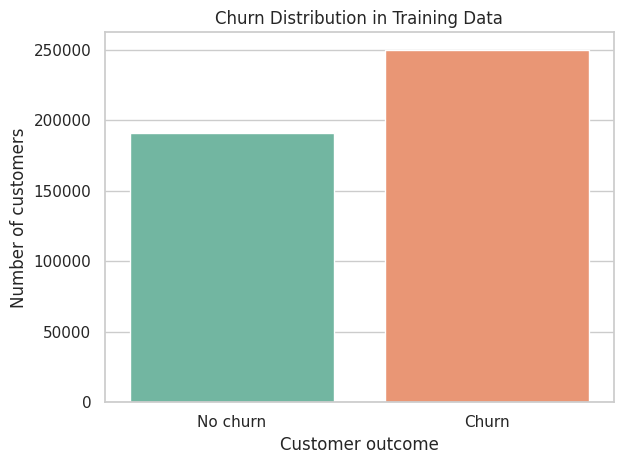

In [5]:
churn_counts = train_df["Churn"].value_counts().sort_index()
churn_percent = (train_df["Churn"].value_counts(normalize=True).sort_index() * 100).round(2)
target_summary = pd.DataFrame({"count": churn_counts, "percentage": churn_percent})
display(target_summary)

ax = sns.countplot(data=train_df, x="Churn", hue="Churn", legend=False)
ax.set_title("Churn Distribution in Training Data")
ax.set_xticks([0, 1], ["No churn", "Churn"])
ax.set_xlabel("Customer outcome")
ax.set_ylabel("Number of customers")
plt.tight_layout()
plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretation:** The target distribution shows whether the classes are balanced. If churners and non-churners are not equally represented, accuracy alone can be misleading, so precision, recall, F1-score, and ROC-AUC are reported later.


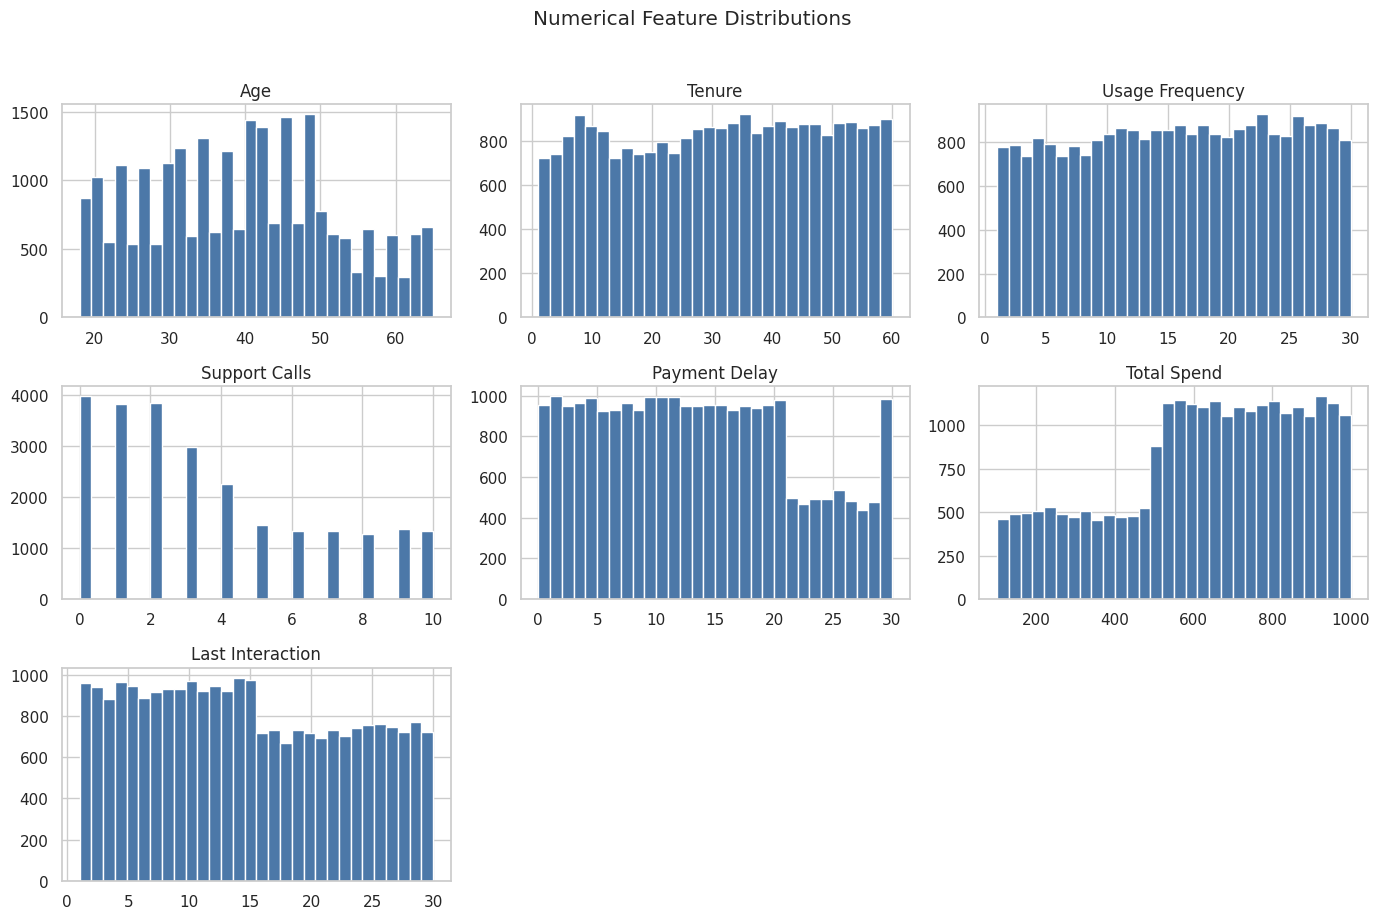

In [6]:
model_feature_columns = [c for c in train_df.columns if c not in ["CustomerID", "Churn"]]
numeric_features = train_df[model_feature_columns].select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in model_feature_columns if c not in numeric_features]

sample_for_eda = train_df.sample(n=min(25000, len(train_df)), random_state=RANDOM_STATE)

sample_for_eda[numeric_features].hist(figsize=(14, 9), bins=30, color="#4c78a8", edgecolor="white")
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


**Interpretation:** The numerical distributions show the range and skew of customer behavior variables. Scaling is useful for Logistic Regression and KNN because distance-based and coefficient-based models are sensitive to feature magnitude.


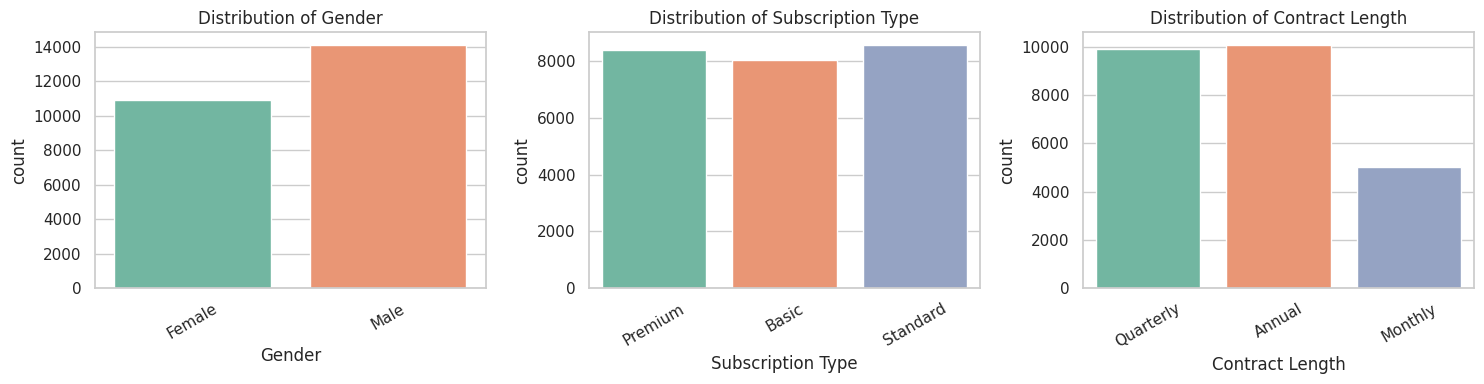

In [7]:
fig, axes = plt.subplots(1, len(categorical_features), figsize=(5 * len(categorical_features), 4))
if len(categorical_features) == 1:
    axes = [axes]
for axis, feature in zip(axes, categorical_features):
    sns.countplot(data=sample_for_eda, x=feature, hue=feature, legend=False, ax=axis)
    axis.set_title(f"Distribution of {feature}")
    axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Interpretation:** Categorical distributions show whether groups such as subscription type or contract length are common enough to provide useful learning signal.


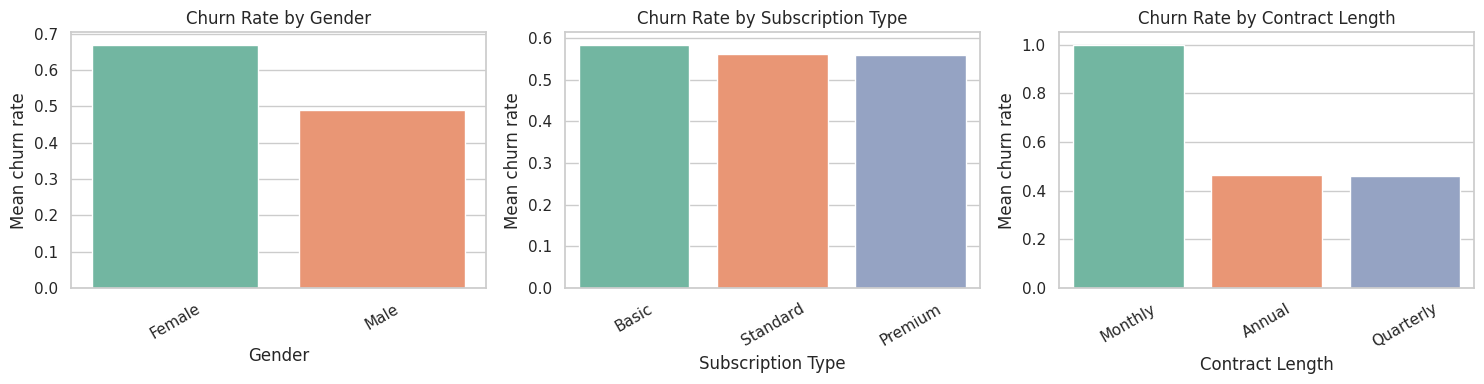

In [8]:
fig, axes = plt.subplots(1, len(categorical_features), figsize=(5 * len(categorical_features), 4))
if len(categorical_features) == 1:
    axes = [axes]
for axis, feature in zip(axes, categorical_features):
    churn_rate = sample_for_eda.groupby(feature)["Churn"].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=churn_rate, x=feature, y="Churn", hue=feature, legend=False, ax=axis)
    axis.set_title(f"Churn Rate by {feature}")
    axis.set_ylabel("Mean churn rate")
    axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Interpretation:** Churn rate by category highlights customer segments that may carry higher risk. These differences justify one-hot encoding categorical features in the preprocessing pipeline.


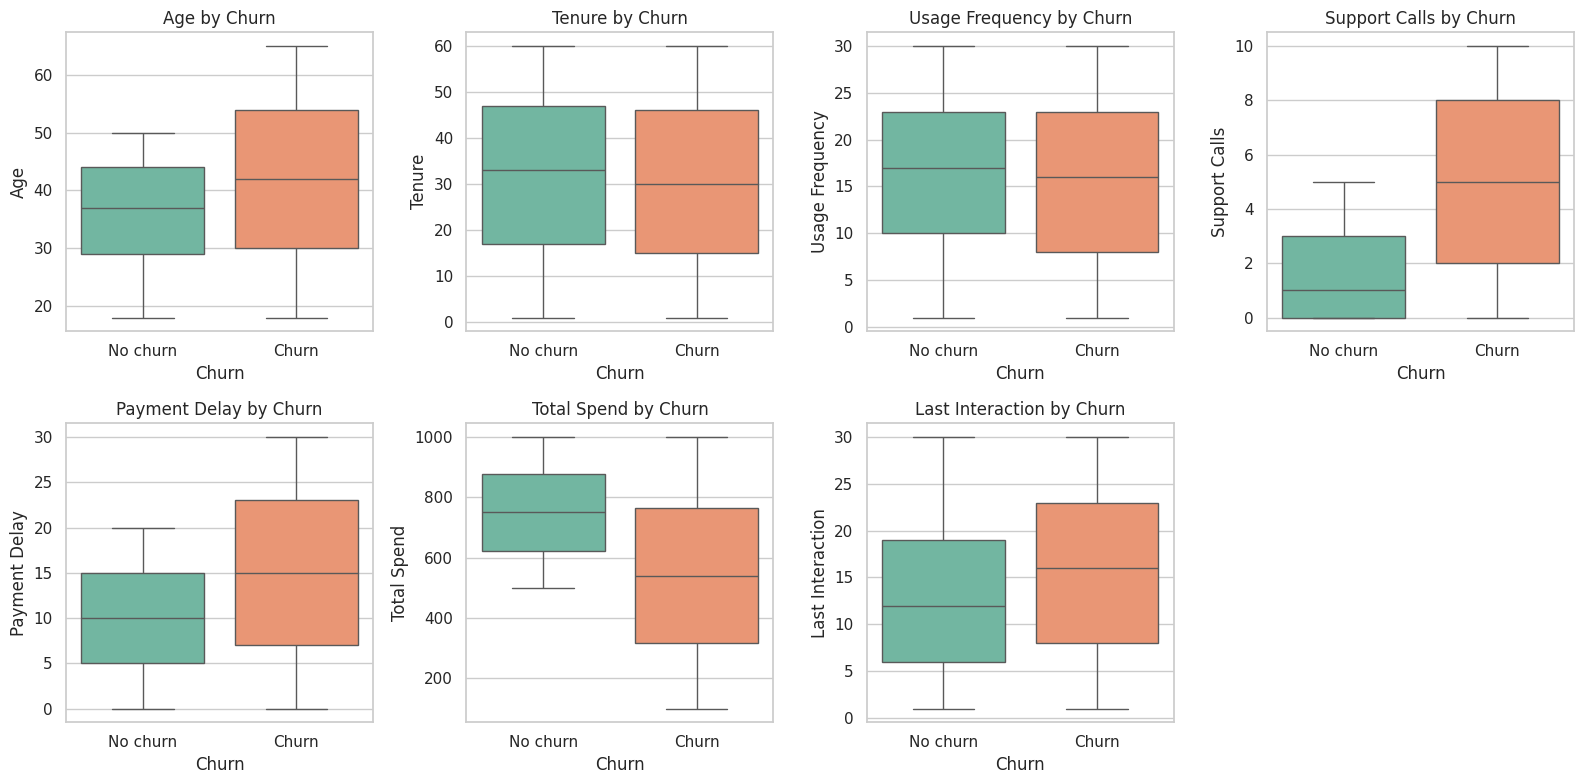

In [9]:
box_features = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend", "Last Interaction"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis, feature in zip(axes.ravel(), box_features):
    sns.boxplot(data=sample_for_eda, x="Churn", y=feature, hue="Churn", legend=False, ax=axis)
    axis.set_title(f"{feature} by Churn")
    axis.set_xticks([0, 1], ["No churn", "Churn"])
for axis in axes.ravel()[len(box_features):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()


**Interpretation:** Boxplots compare customer behavior between churn classes. Features whose medians or spreads differ by churn class are likely to be useful predictors.


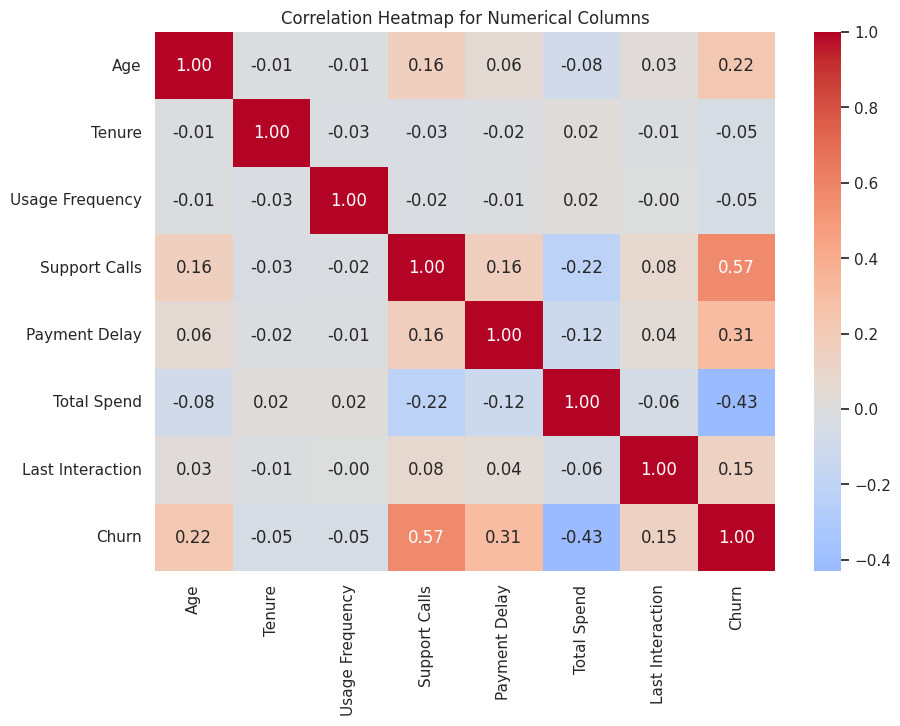

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(train_df[numeric_features + ["Churn"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Numerical Columns")
plt.show()


**Interpretation:** Correlation helps identify numerical variables associated with churn and also shows whether some predictors overlap strongly with each other.


## 6. Preprocessing Workflow

A full scikit-learn pipeline is used to avoid data leakage. Numerical imputation, categorical imputation, one-hot encoding, and scaling are fit inside each cross-validation fold rather than before the train/test split.

- **Numerical pipeline:** median imputation and standard scaling.
- **Categorical pipeline:** most-frequent imputation and `OneHotEncoder(handle_unknown="ignore")`.
- **ColumnTransformer:** applies the correct transformation to each feature type.


In [11]:
feature_columns = model_feature_columns
target_column = "Churn"

X_train_full = train_df[feature_columns]
y_train_full = train_df[target_column]
X_test_full = test_df[feature_columns]
y_test_full = test_df[target_column]

train_sample_size = min(TRAIN_SAMPLE_SIZE, len(train_df))
test_eval_size = min(TEST_EVAL_SIZE, len(test_df))

train_model_df = train_df.groupby("Churn", group_keys=False).sample(
    frac=train_sample_size / len(train_df),
    random_state=RANDOM_STATE,
)
if len(train_model_df) > train_sample_size:
    train_model_df = train_model_df.sample(n=train_sample_size, random_state=RANDOM_STATE)

test_eval_df = test_df.groupby("Churn", group_keys=False).sample(
    frac=test_eval_size / len(test_df),
    random_state=RANDOM_STATE,
)
if len(test_eval_df) > test_eval_size:
    test_eval_df = test_eval_df.sample(n=test_eval_size, random_state=RANDOM_STATE)

baseline_train_df, validation_df = train_test_split(
    train_model_df,
    test_size=0.20,
    stratify=train_model_df[target_column],
    random_state=RANDOM_STATE,
)

X_baseline_train = baseline_train_df[feature_columns]
y_baseline_train = baseline_train_df[target_column]
X_valid = validation_df[feature_columns]
y_valid = validation_df[target_column]

X_train = train_model_df[feature_columns]
y_train = train_model_df[target_column]
X_test = test_eval_df[feature_columns]
y_test = test_eval_df[target_column]

def build_preprocessor() -> ColumnTransformer:
    """Create a fresh preprocessing transformer for each model pipeline."""
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])

preprocessor = build_preprocessor()

print("Training rows available:", X_train_full.shape[0])
print("Testing rows available:", X_test_full.shape[0])
print("Rows used for baseline/tuning sample:", X_train.shape[0])
print("Rows used for baseline fit:", X_baseline_train.shape[0])
print("Rows used for internal baseline validation:", X_valid.shape[0])
print("Rows used for final evaluation:", X_test.shape[0])
print("Feature columns:", feature_columns)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Training rows available: 440832
Testing rows available: 64374
Rows used for baseline/tuning sample: 6000
Rows used for baseline fit: 4800
Rows used for internal baseline validation: 1200
Rows used for final evaluation: 4000
Feature columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']
Numerical features: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
Categorical features: ['Gender', 'Subscription Type', 'Contract Length']


## 7. Train/Test Strategy

The dataset already provides separate training and testing files. The testing file is treated as a final holdout set and is not used for preprocessing fits, model training, or hyperparameter selection.

The training file is split into two classroom-friendly pieces: an internal validation subset for untuned baseline models, and a cross-validation training sample for hyperparameter tuning. This keeps baseline comparison visible while preserving the provided testing file for the final tuned evaluation.

A stratified reproducible sample is used for classroom runtime because the source dataset is large. The sampling keeps churn class proportions stable and never mixes training rows with testing rows.

## 8. Model Intuition and Justification

Three required models are compared fairly using the same features, preprocessing, training sample, cross-validation strategy, and final test sample.

### Logistic Regression

Logistic Regression is a linear classification model that estimates the probability of churn from a weighted sum of transformed features.

- **Why chosen:** it is simple, fast, interpretable, and provides a strong baseline.
- **Important hyperparameters:** `C` controls regularization strength, `solver` controls the optimization algorithm, and `class_weight` can compensate for class imbalance.
- **Strengths:** interpretable, efficient, good calibrated probabilities in many settings.
- **Weaknesses:** may underfit if the relationship between features and churn is highly non-linear.

### K-Nearest Neighbors (KNN)

KNN predicts a customer's churn class by looking at the most similar customers in the training data.

- **Why chosen:** it is intuitive and useful for detecting similarity-based customer behavior patterns.
- **Important hyperparameters:** `n_neighbors`, `weights`, and distance `metric`.
- **Strengths:** simple idea, non-parametric, can capture local patterns.
- **Weaknesses:** sensitive to scaling, can be slower at prediction time, and can struggle in high-dimensional one-hot encoded spaces.

### Random Forest Classifier

Random Forest combines many decision trees and aggregates their predictions.

- **Why chosen:** it captures non-linear relationships and feature interactions common in churn behavior.
- **Important hyperparameters:** `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `class_weight`.
- **Strengths:** strong performance, handles mixed patterns well, provides feature importance.
- **Weaknesses:** less transparent than Logistic Regression and can overfit if trees are not controlled.


## 9. Untuned Baseline Models

Before tuning, each required model is trained with sensible default settings and evaluated on an internal validation split from the training file. This provides a simple baseline and makes the effect of hyperparameter tuning easier to interpret.

In [12]:
baseline_models = {
    "Logistic Regression": Pipeline([
        ("preprocess", build_preprocessor()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("preprocess", build_preprocessor()),
        ("classifier", KNeighborsClassifier()),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", build_preprocessor()),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)),
    ]),
}

baseline_rows = []
for model_name, model in baseline_models.items():
    model.fit(X_baseline_train, y_baseline_train)
    y_valid_pred = model.predict(X_valid)
    y_valid_proba = model.predict_proba(X_valid)[:, 1]
    baseline_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_valid_pred),
        "Precision": precision_score(y_valid, y_valid_pred, zero_division=0),
        "Recall": recall_score(y_valid, y_valid_pred, zero_division=0),
        "F1": f1_score(y_valid, y_valid_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_valid, y_valid_proba),
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values(["F1", "Recall", "ROC-AUC"], ascending=False)
baseline_rounded = baseline_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    baseline_rounded[col] = baseline_rounded[col].round(4)

display(baseline_rounded)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.9842,0.9911,0.9809,0.9860,0.9981
1,KNN,0.9142,0.9949,0.8532,0.9186,0.9763
0,Logistic Regression,0.9017,0.9233,0.9016,0.9123,0.9594


## 10. Hyperparameter Tuning

The primary optimization metric is **F1-score**. In churn prediction, recall matters because missed churners represent lost retention opportunities, but precision also matters because retention campaigns cost money. F1-score balances both concerns more directly than accuracy.

`GridSearchCV` is used for Logistic Regression and KNN because their search spaces are compact. `RandomizedSearchCV` is used for Random Forest to sample a wider tree-parameter space efficiently.

In [13]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

model_specs = {
    "Logistic Regression": {
        "search_type": "grid",
        "pipeline": Pipeline([
            ("preprocess", build_preprocessor()),
            ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]),
        "params": {
            "classifier__C": [0.1, 1.0, 10.0],
            "classifier__solver": ["liblinear"],
            "classifier__class_weight": [None, "balanced"],
        },
    },
    "KNN": {
        "search_type": "grid",
        "pipeline": Pipeline([
            ("preprocess", build_preprocessor()),
            ("classifier", KNeighborsClassifier()),
        ]),
        "params": {
            "classifier__n_neighbors": [5, 11],
            "classifier__weights": ["uniform", "distance"],
            "classifier__metric": ["minkowski", "manhattan"],
        },
    },
    "Random Forest": {
        "search_type": "random",
        "pipeline": Pipeline([
            ("preprocess", build_preprocessor()),
            ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [8, 16, None],
            "classifier__min_samples_split": [2, 10],
            "classifier__min_samples_leaf": [1, 4],
            "classifier__class_weight": [None, "balanced"],
        },
    },
}

fitted_models = {}
tuning_rows = []

for model_name, spec in model_specs.items():
    print(f"Tuning {model_name}...")
    if spec["search_type"] == "random":
        search = RandomizedSearchCV(
            spec["pipeline"],
            spec["params"],
            n_iter=6,
            scoring="f1",
            cv=cv,
            n_jobs=1,
            random_state=RANDOM_STATE,
            refit=True,
        )
    else:
        search = GridSearchCV(
            spec["pipeline"],
            spec["params"],
            scoring="f1",
            cv=cv,
            n_jobs=1,
            refit=True,
        )
    search.fit(X_train, y_train)
    fitted_models[model_name] = search.best_estimator_
    tuning_rows.append({
        "Model": model_name,
        "Search Method": type(search).__name__,
        "Best CV F1": round(float(search.best_score_), 4),
        "Best Parameters": search.best_params_,
    })

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df)

Tuning Logistic Regression...
Tuning KNN...
Tuning Random Forest...


,Model,Search Method,Best CV F1,Best Parameters
0,Logistic Regression,GridSearchCV,0.9124,"{'classifier__C': 10.0, 'classifier__class_wei..."
1,KNN,GridSearchCV,0.9162,"{'classifier__metric': 'minkowski', 'classifie..."
2,Random Forest,RandomizedSearchCV,0.9901,"{'classifier__n_estimators': 100, 'classifier_..."


## 11. Final Evaluation and Fair Model Comparison

All tuned models are evaluated on the same unseen testing data. The metrics are:

- **Accuracy:** total percentage of correct predictions.
- **Precision:** among predicted churners, how many actually churned.
- **Recall:** among actual churners, how many were found.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** ability to separate churners from non-churners across thresholds.


In [14]:
metric_rows = []
roc_rows = []
confusion_rows = []
classification_reports = {}

for model_name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metric_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_rows.extend(
        {"Model": model_name, "FPR": float(f), "TPR": float(t), "Threshold": float(th)}
        for f, t, th in zip(fpr, tpr, thresholds)
    )

    matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
    for actual_idx, actual_label in enumerate(["No churn", "Churn"]):
        for pred_idx, pred_label in enumerate(["No churn", "Churn"]):
            confusion_rows.append({
                "Model": model_name,
                "Actual": actual_label,
                "Predicted": pred_label,
                "Count": int(matrix[actual_idx, pred_idx]),
            })

    classification_reports[model_name] = classification_report(
        y_test,
        y_pred,
        target_names=["No churn", "Churn"],
        output_dict=True,
        zero_division=0,
    )

metrics_df = pd.DataFrame(metric_rows).sort_values(["F1", "Recall", "ROC-AUC"], ascending=False)
metrics_rounded = metrics_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    metrics_rounded[col] = metrics_rounded[col].round(4)

roc_df = pd.DataFrame(roc_rows)
confusion_df = pd.DataFrame(confusion_rows)

display(metrics_rounded)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5775,0.5288,0.9921,0.6899,0.7007
1,KNN,0.5848,0.5342,0.9641,0.6875,0.6609
2,Random Forest,0.5158,0.4945,0.9979,0.6613,0.6831


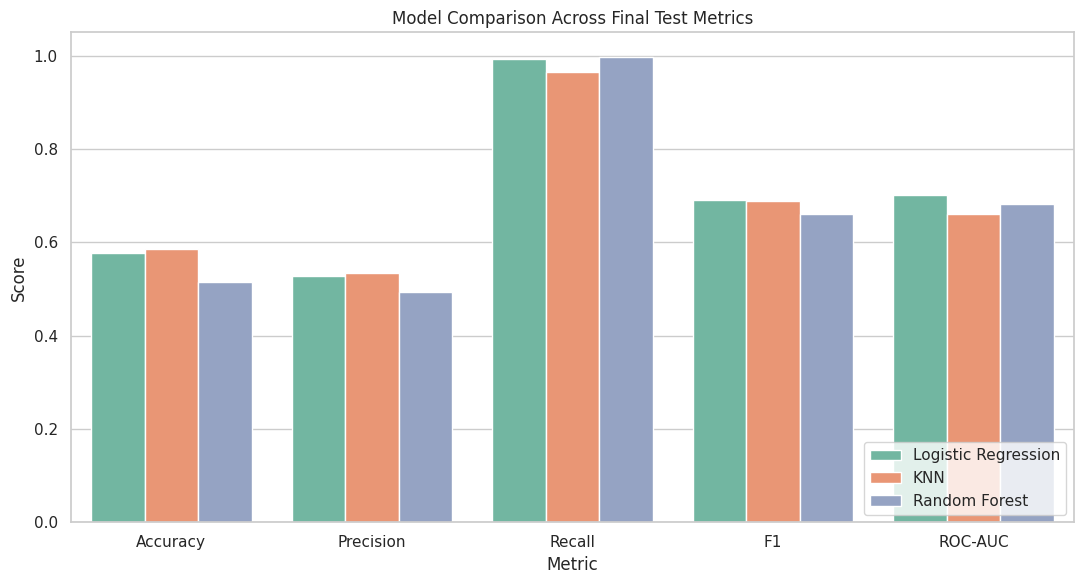

In [15]:
metric_long = metrics_rounded.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=metric_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Model Comparison Across Final Test Metrics")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretation:** The comparison chart makes the trade-off between recall, precision, F1-score, and ROC-AUC visible. The preferred model should perform well on F1 and recall while maintaining reliable overall separation.


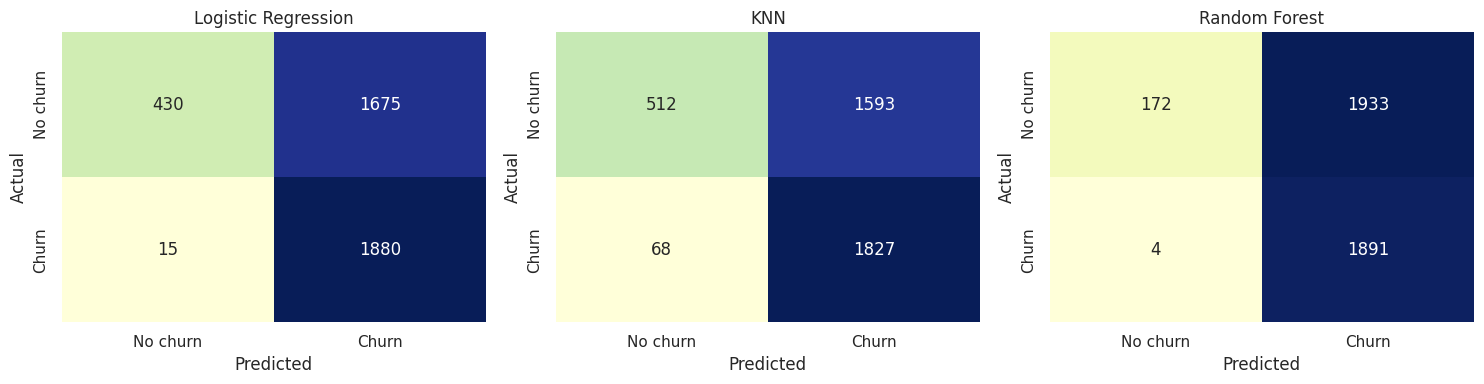

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, model_name in zip(axes, fitted_models.keys()):
    sub = confusion_df[confusion_df["Model"] == model_name]
    matrix = sub.pivot(index="Actual", columns="Predicted", values="Count").loc[
        ["No churn", "Churn"], ["No churn", "Churn"]
    ]
    sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=False, ax=axis)
    axis.set_title(model_name)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretation:** Confusion matrices show the actual business errors. False negatives are churners incorrectly predicted as staying, and false positives are staying customers incorrectly flagged for intervention.


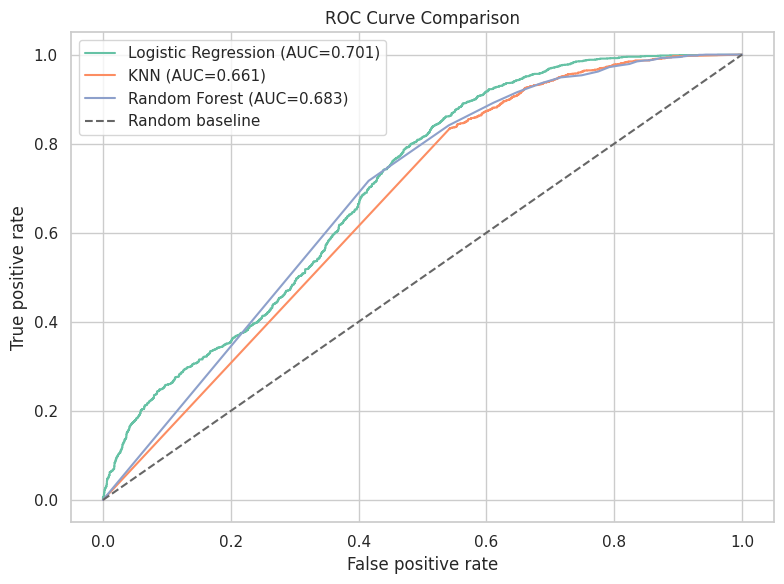

In [17]:
plt.figure(figsize=(8, 6))
for model_name in fitted_models.keys():
    sub = roc_df[roc_df["Model"] == model_name]
    auc_value = metrics_rounded.loc[metrics_rounded["Model"] == model_name, "ROC-AUC"].iloc[0]
    plt.plot(sub["FPR"], sub["TPR"], label=f"{model_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="#666666", label="Random baseline")
plt.title("ROC Curve Comparison")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretation:** ROC curves compare ranking ability across decision thresholds. A curve closer to the top-left corner indicates stronger separation between churners and non-churners.


In [18]:
for model_name, report in classification_reports.items():
    print(f"\nClassification report: {model_name}")
    display(pd.DataFrame(report).T.round(4))



Classification report: Logistic Regression


,precision,recall,f1-score,support
No churn,0.9663,0.2043,0.3373,2105.0000
Churn,0.5288,0.9921,0.6899,1895.0000
accuracy,0.5775,0.5775,0.5775,0.5775
macro avg,0.7476,0.5982,0.5136,4000.0000
weighted avg,0.7590,0.5775,0.5043,4000.0000



Classification report: KNN


,precision,recall,f1-score,support
No churn,0.8828,0.2432,0.3814,2105.0000
Churn,0.5342,0.9641,0.6875,1895.0000
accuracy,0.5848,0.5848,0.5848,0.5848
macro avg,0.7085,0.6037,0.5344,4000.0000
weighted avg,0.7176,0.5848,0.5264,4000.0000



Classification report: Random Forest


,precision,recall,f1-score,support
No churn,0.9773,0.0817,0.1508,2105.0000
Churn,0.4945,0.9979,0.6613,1895.0000
accuracy,0.5158,0.5158,0.5158,0.5158
macro avg,0.7359,0.5398,0.4061,4000.0000
weighted avg,0.7486,0.5158,0.3927,4000.0000


## 12. Final Model Selection

The final model is selected using test-set F1-score as the primary criterion, with recall and ROC-AUC used as supporting evidence. This is appropriate for churn prediction because the business wants to catch likely churners without creating too many false alerts.


In [19]:
best_model_name = metrics_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_metrics = metrics_rounded[metrics_rounded["Model"] == best_model_name]

print("Selected final model:", best_model_name)
display(best_metrics)


Selected final model: Logistic Regression


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5775,0.5288,0.9921,0.6899,0.7007


**Selection explanation:** The selected model is preferred because it gives the strongest F1-score on unseen testing data while still considering recall, precision, and ROC-AUC. In business terms, this means it balances the cost of missed churners against the cost of unnecessary retention actions better than the alternatives.


,Feature,Importance
13,Contract Length = Monthly,6.046654
14,Contract Length = Quarterly,2.729919
12,Contract Length = Annual,2.648295
3,Support Calls,2.332964
5,Total Spend,1.484111
7,Gender_Female,0.927823
4,Payment Delay,0.895530
6,Last Interaction,0.527751
0,Age,0.513066
9,Subscription Type = Basic,0.339121


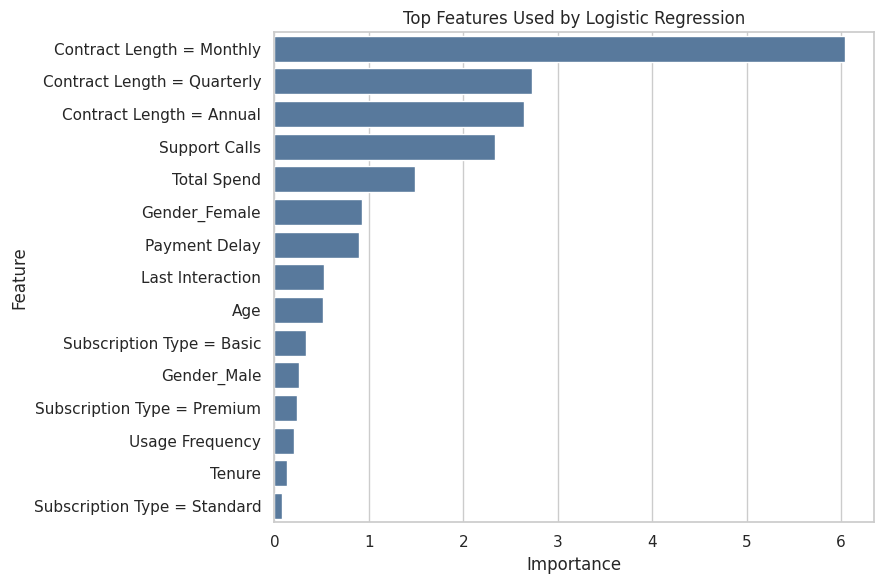

In [20]:
def clean_feature_name(name: str) -> str:
    return (
        name.replace("num__", "")
        .replace("cat__", "")
        .replace("Subscription Type_", "Subscription Type = ")
        .replace("Contract Length_", "Contract Length = ")
    )

feature_names = [clean_feature_name(name) for name in best_model.named_steps["preprocess"].get_feature_names_out()]
classifier = best_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):
    importance_values = classifier.feature_importances_
elif hasattr(classifier, "coef_"):
    importance_values = np.abs(classifier.coef_).ravel()
else:
    importance_values = np.zeros(len(feature_names))

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importance_values})
    .sort_values("Importance", ascending=False)
    .head(15)
)

display(importance_df)
plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", color="#4c78a8")
plt.title(f"Top Features Used by {best_model_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()


## 13. Inference on New Data

The final selected pipeline can be used on unseen customer profiles. The examples below are manually created profiles, not rows copied from the training data.


In [21]:
new_customers = pd.DataFrame([
    {
        "Age": 24,
        "Gender": "Female",
        "Tenure": 4,
        "Usage Frequency": 5,
        "Support Calls": 8,
        "Payment Delay": 28,
        "Subscription Type": "Basic",
        "Contract Length": "Monthly",
        "Total Spend": 220,
        "Last Interaction": 26,
    },
    {
        "Age": 46,
        "Gender": "Male",
        "Tenure": 48,
        "Usage Frequency": 24,
        "Support Calls": 1,
        "Payment Delay": 2,
        "Subscription Type": "Premium",
        "Contract Length": "Annual",
        "Total Spend": 890,
        "Last Interaction": 4,
    },
    {
        "Age": 61,
        "Gender": "Female",
        "Tenure": 18,
        "Usage Frequency": 11,
        "Support Calls": 5,
        "Payment Delay": 17,
        "Subscription Type": "Standard",
        "Contract Length": "Quarterly",
        "Total Spend": 540,
        "Last Interaction": 14,
    },
])

new_predictions = new_customers.copy()
new_predictions["Predicted Churn"] = best_model.predict(new_customers)
new_predictions["Churn Probability"] = best_model.predict_proba(new_customers)[:, 1]
new_predictions["Interpretation"] = np.where(
    new_predictions["Predicted Churn"].eq(1),
    "Retention action recommended",
    "Lower churn risk based on current profile",
)

display(new_predictions)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Predicted Churn,Churn Probability,Interpretation
0,24,Female,4,5,8,28,Basic,Monthly,220,26,1,1.000000,Retention action recommended
1,46,Male,48,24,1,2,Premium,Annual,890,4,0,0.005258,Lower churn risk based on current profile
2,61,Female,18,11,5,17,Standard,Quarterly,540,14,1,0.986084,Retention action recommended


## 14. Save Model Artifacts for Dashboard

The dashboard should load a complete pipeline, including preprocessing and the final classifier. Saving only the bare classifier would fail because raw customer inputs still need imputation, scaling, and one-hot encoding.


In [22]:
model_path = MODEL_DIR / "churn_prediction_model.pkl"
joblib.dump(best_model, model_path)

metrics_rounded.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
baseline_rounded.to_csv(OUTPUT_DIR / "baseline_metrics.csv", index=False)
tuning_export = tuning_df.copy()
tuning_export["Best Parameters"] = tuning_export["Best Parameters"].astype(str)
tuning_export.to_csv(OUTPUT_DIR / "tuning_summary.csv", index=False)
roc_df.to_csv(OUTPUT_DIR / "roc_curves.csv", index=False)
confusion_df.to_csv(OUTPUT_DIR / "confusion_matrices.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
new_predictions.to_csv(OUTPUT_DIR / "sample_predictions.csv", index=False)

profile = {
    "best_model": best_model_name,
    "model_path": str(model_path.relative_to(PROJECT_DIR)),
    "training_file": str(TRAIN_PATH.relative_to(PROJECT_DIR)),
    "testing_file": str(TEST_PATH.relative_to(PROJECT_DIR)),
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "numeric_ranges": {
        feature: {
            "min": float(train_df[feature].min()),
            "max": float(train_df[feature].max()),
            "median": float(train_df[feature].median()),
        }
        for feature in numeric_features
    },
    "categories": {
        feature: sorted(train_df[feature].dropna().astype(str).unique().tolist())
        for feature in categorical_features
    },
    "train_rows_available": int(len(train_df)),
    "test_rows_available": int(len(test_df)),
    "train_rows_used": int(len(X_train)),
    "test_rows_used": int(len(X_test)),
    "primary_metric": "F1-score",
}

(OUTPUT_DIR / "data_profile.json").write_text(json.dumps(profile, indent=2), encoding="utf-8")

print("Saved final model pipeline to:", model_path)
print("Saved dashboard artifacts to:", OUTPUT_DIR)


Saved final model pipeline to: /workspaces/New-project/models/churn_prediction_model.pkl
Saved dashboard artifacts to: /workspaces/New-project/outputs


## 15. Conclusion

This project built a complete customer churn prediction workflow using supervised machine learning. The notebook loaded the provided training and testing datasets from `dataset/`, cleaned the target, inspected the data, explored churn patterns, built leakage-safe preprocessing pipelines, tuned Logistic Regression, KNN, and Random Forest, compared them on unseen test data, selected a final model using business-aware metrics, and demonstrated inference on new customer profiles.

The main limitation is that the dataset appears to be structured and tabular without richer customer history such as transaction sequences, complaint text, or intervention outcomes. Future improvements could include threshold optimization based on retention cost, probability calibration analysis, fairness checks across customer groups, and testing on newer real-world data.
